Загрузка библиотек

In [132]:
!pip install pandas

In [133]:
!pip install matplotlib

In [134]:
!pip install seaborn 

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка базы данных/файла с данными 

In [136]:
realty = pd.read_csv(r'C:/Users/Zere/Downloads/real_estate_ads (1).csv', delimiter=',')

# 2. Обзор и обработка данных

In [137]:
realty.info()   # Информация о датасете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23699 non-null  object 
 15  airports_nearest   

Итог. Ошибочные типы в базе данных и их замена на корректный тип данных:
1. Тип first_day_exposition преобразуем в формат даты (datetime) с помощью pd.to_datetime.
2. Тип floors_total преобразуем в целое число (int), так как количество этажей не может быть дробным.
3. Тип balcony преобразуем в целое число (int).
4. Тип is_apartment преобразуйем в булев тип (bool).
5. Тип parks_around3000 и ponds_around3000 преобразуем в целое число (int).
6. Тип category преобразуем в текстовый тип (object) для экономии памяти.

In [138]:
realty.head(10)  # Выводим первые 10 строк

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category
0,20,39000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,NaN,Город А,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,Город
1,7,10050000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,2.0,Посёлок 1,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,Посёлок
2,10,15588000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,0.0,Город А,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,Город
3,0,194700000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,0.0,Город А,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,Город
4,2,30000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,NaN,Город А,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,Город
5,10,8670000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,NaN,Посёлок 2,NaN,NaN,NaN,NaN,NaN,NaN,55.0,Посёлок
6,6,11100000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,1.0,Посёлок 3,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0,Посёлок
7,5,23745000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,2.0,Город А,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN,Город
8,20,8700000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,NaN,Посёлок 4,NaN,NaN,NaN,NaN,NaN,NaN,189.0,Посёлок
9,18,16200000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,2.0,Город А,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0,Город


In [139]:
realty.tail(10)  # Выводим последние 10 строк

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category
23689,13,10650000.0,35.30,2018-02-28T00:00:00,1,2.86,15.0,16.3,4,NaN,...,2.0,Город А,17284.0,16081.0,1.0,353.0,2.0,652.0,29.0,Город
23690,3,16500000.0,52.00,2018-07-19T00:00:00,2,NaN,5.0,31.0,2,NaN,...,NaN,Город А,20151.0,6263.0,1.0,300.0,0.0,NaN,15.0,Город
23691,11,28410000.0,72.90,2016-10-13T00:00:00,2,2.75,25.0,40.3,7,NaN,...,1.0,Город А,19424.0,4489.0,0.0,NaN,1.0,806.0,519.0,Город
23692,2,4050000.0,30.00,2017-07-07T00:00:00,1,NaN,5.0,17.5,4,NaN,...,NaN,Населённый пункт 31,NaN,NaN,NaN,NaN,NaN,NaN,413.0,Населённый пункт
23693,9,13800000.0,62.40,2016-08-05T00:00:00,3,2.60,9.0,40.0,8,NaN,...,0.0,Населённый пункт 3,45602.0,34104.0,1.0,352.0,1.0,675.0,239.0,Населённый пункт
23694,9,29100000.0,133.81,2017-03-21T00:00:00,3,3.70,5.0,73.3,3,NaN,...,NaN,Город А,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN,Город
23695,14,9300000.0,59.00,2018-01-15T00:00:00,3,NaN,5.0,38.0,4,NaN,...,NaN,Населённый пункт 32,NaN,NaN,NaN,NaN,NaN,NaN,45.0,Населённый пункт
23696,18,7500000.0,56.70,2018-02-11T00:00:00,2,NaN,3.0,29.7,1,NaN,...,NaN,Село 9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Село
23697,13,34425000.0,76.75,2017-03-28T00:00:00,2,3.00,17.0,NaN,12,NaN,...,2.0,Город А,39140.0,10364.0,2.0,173.0,3.0,196.0,602.0,Город
23698,4,4050000.0,32.30,2017-07-21T00:00:00,1,2.50,5.0,12.3,1,NaN,...,NaN,Посёлок 127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Посёлок


Итог. В таблице присутсвует информации о:
- расстояние до ближайшего аэропорта в метрах (м);
- число балконов;
- высота потолков (м);
- расстояние до центра города (м);
- тип населенного пункта (город, село, деревня, поселок, населенный пункт);
- сколько дней было размещено объявление (от публикации до снятия);
- дата публикации;
- этаж;
- всего этажей в доме;
- апартаменты (булев тип);
- площадь кухни в квадратных метрах (м²);
- цена на момент снятия с публикации;
- жилая площадь в квадратных метрах (м²);
- название населённого пункта;
- свободная планировка (булев тип);
- число парков в радиусе 3 км;
- расстояние до ближайшего парка (м);
- число водоёмов в радиусе 3 км;
- расстояние до ближайшего водоёма (м);
- число комнат;
- квартира-студия (булев тип);
- площадь квартиры в квадратных метрах (м²);
- число фотографий квартиры в объявлении. 

In [140]:
pd.isnull(realty).sum()   # Информация о наличии пропусках

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name               0
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
category                    0
dtype: int64

In [141]:
realty.describe()  # Выводим числовые колонки

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
count,23699.000000,2.369900e+04,23699.000000,23699.000000,14504.000000,23613.000000,21796.000000,23699.000000,21421.000000,12180.000000,18157.000000,18180.000000,18181.000000,8079.000000,18181.000000,9110.000000,20518.000000
mean,9.858475,1.962465e+07,60.348651,2.070636,2.771499,10.673824,34.457852,5.892358,10.569807,1.150082,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.980900,180.888634
std,5.682529,3.266104e+07,35.654083,1.078405,1.261056,6.597173,22.030445,4.885249,5.905438,1.071300,12630.880622,8608.386210,0.802074,342.317995,0.938346,277.720643,219.727988
min,0.000000,3.657000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000,0.000000,1.000000,0.000000,13.000000,1.000000
25%,6.000000,1.020000e+07,40.000000,1.000000,2.520000,5.000000,18.600000,2.000000,7.000000,0.000000,18585.000000,9238.000000,0.000000,288.000000,0.000000,294.000000,45.000000
50%,9.000000,1.395000e+07,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.100000,1.000000,26726.000000,13098.500000,0.000000,455.000000,1.000000,502.000000,95.000000
75%,14.000000,2.040000e+07,69.900000,3.000000,2.800000,16.000000,42.300000,8.000000,12.000000,2.000000,37273.000000,16293.000000,1.000000,612.000000,1.000000,729.000000,232.000000
max,50.000000,2.289000e+09,900.000000,19.000000,100.000000,60.000000,409.700000,33.000000,112.000000,5.000000,84869.000000,65968.000000,3.000000,3190.000000,3.000000,1344.000000,1580.000000


Итог. Возможные ошибочные данные в столбцах:
1. total_area (S квартиры) максимальное значение 900 кв.м
2. rooms (число комнат) минимальное значение равна 0
3. ceiling_height (высота потолков) минимальное значение 1 м и максимальное значение 100 м
4. floors_total (всего этажей в доме) максимальное значение 60
5. living_area (жилая S) минимальное значение равна 2 кв.м
6. kitchen_area (S кухни) минимальное значение 1.3 кв.м и максимальное значение 112 кв.м
7. days_exposition максимальное значение 1580 дней, что означает 4,3 года

1. 900 м2 показалось большим значением для квартиры. Я решила посмотреть квартиры с большой квадратурой, а точнее посмотреть все квартиры больше 200 м2.

In [142]:
realty[realty["total_area"] >  200 ]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category
155,8,288000000.0,317.0,2017-07-07T00:00:00,4,3.50,3.0,183.0,3,NaN,...,1.0,Город А,22673.0,1771.0,2.0,508.0,3.0,366.0,62.0,Город
464,15,199713000.0,280.3,2015-06-11T00:00:00,6,5.20,8.0,159.5,7,NaN,...,0.0,Город А,26316.0,6655.0,3.0,187.0,1.0,616.0,578.0,Город
492,18,285000000.0,216.0,2017-12-05T00:00:00,4,3.00,5.0,86.0,4,NaN,...,NaN,Город А,21740.0,436.0,2.0,138.0,3.0,620.0,14.0,Город
509,5,270000000.0,225.0,2016-06-26T00:00:00,6,NaN,4.0,134.0,2,NaN,...,2.0,Город А,32864.0,5720.0,0.0,NaN,2.0,519.0,416.0,Город
521,20,77151900.0,230.1,2015-01-21T00:00:00,3,NaN,3.0,130.0,1,NaN,...,1.0,Населённый пункт 4,16877.0,29030.0,2.0,676.0,3.0,278.0,1441.0,Населённый пункт
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23005,20,92250000.0,297.5,2018-09-09T00:00:00,6,3.14,4.0,181.8,2,NaN,...,NaN,Город А,20630.0,1229.0,3.0,189.0,3.0,40.0,42.0,Город
23281,20,74400000.0,231.2,2015-01-21T00:00:00,6,3.10,5.0,99.8,4,NaN,...,NaN,Город А,21480.0,2453.0,3.0,75.0,1.0,795.0,NaN,Город
23327,19,103200000.0,215.0,2019-03-15T00:00:00,5,2.75,4.0,82.4,4,NaN,...,NaN,Город А,37268.0,15419.0,0.0,NaN,0.0,NaN,NaN,Город
23400,17,90000000.0,213.0,2017-09-28T00:00:00,7,3.40,5.0,151.4,5,NaN,...,NaN,Город А,21146.0,1225.0,2.0,342.0,3.0,30.0,299.0,Город


Для лучшего восприятия построю график и сделаем из этого анализ.

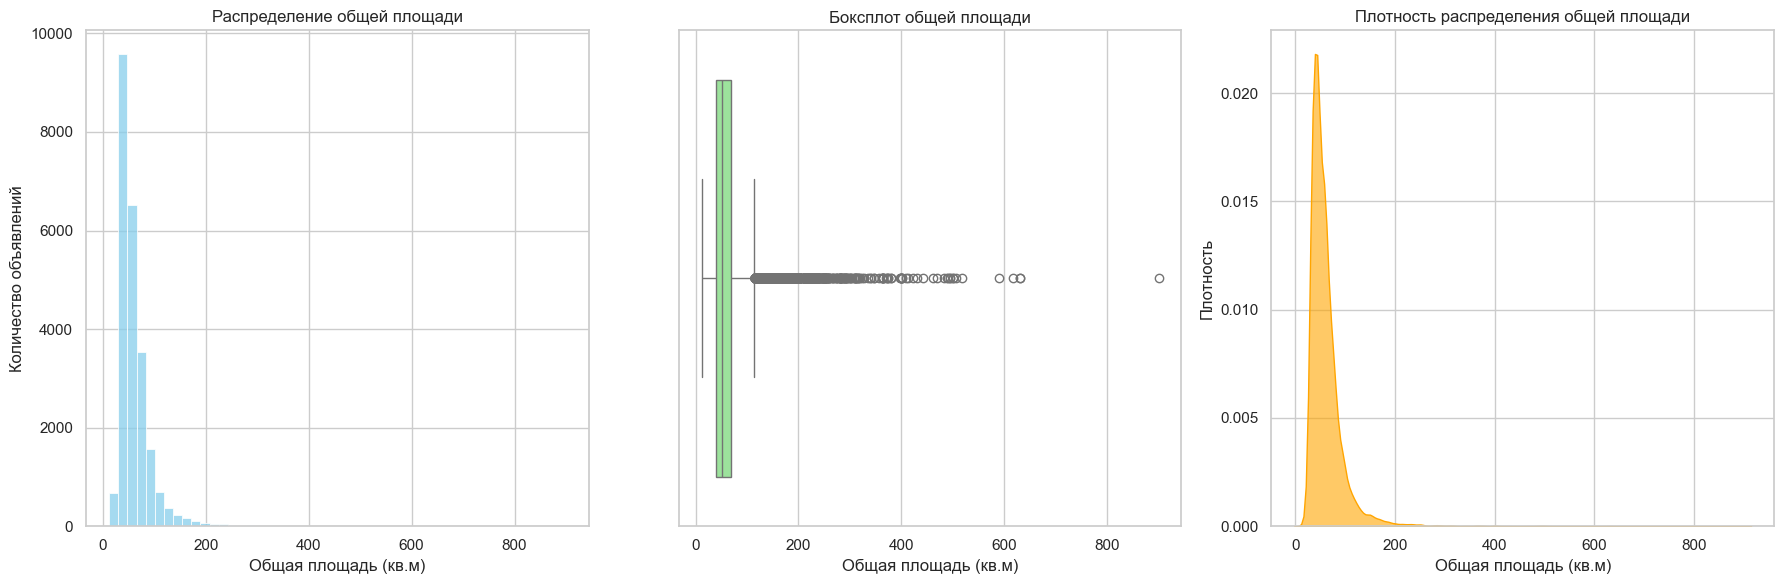

In [143]:
sns.set(style="whitegrid")
plt.figure(figsize=(18, 6))
# 1. Гистограмма
plt.subplot(1, 3, 1)
sns.histplot(data=realty, x='total_area', bins=50, kde=False, color='skyblue')
plt.title('Распределение общей площади')
plt.xlabel('Общая площадь (кв.м)')
plt.ylabel('Количество объявлений')
# 2. Боксплот
plt.subplot(1, 3, 2)
sns.boxplot(data=realty, x='total_area', color='lightgreen')
plt.title('Боксплот общей площади')
plt.xlabel('Общая площадь (кв.м)')
# 3. KDE-график
plt.subplot(1, 3, 3)
sns.kdeplot(data=realty, x='total_area', fill=True, color='orange', alpha=0.6)
plt.title('Плотность распределения общей площади')
plt.xlabel('Общая площадь (кв.м)')
plt.ylabel('Плотность')
# Отображение графиков
plt.tight_layout()
plt.show()

Гистограмма: Показывает, как часто встречаются значения total_area. Это помогает понять, где сосредоточено большинство данных.
Боксплот: Указывает на наличие выбросов и распределение данных. Если есть выбросы (значения выше верхнего уса), их нужно проверить.
KDE-график: Демонстрирует сглаженное распределение данных. Подходит для оценки тенденций и сравнения с другими переменными.

In [144]:
# Удаление значений за пределами диапазона 30-200 кв.м
filtered_data = realty[(realty['total_area'] >= 30) & (realty['total_area'] <= 200)]

# Проверка результата
print(f"Размер данных до фильтрации: {realty.shape[0]}")
print(f"Размер данных после фильтрации: {filtered_data.shape[0]}")

Размер данных до фильтрации: 23699
Размер данных после фильтрации: 22779


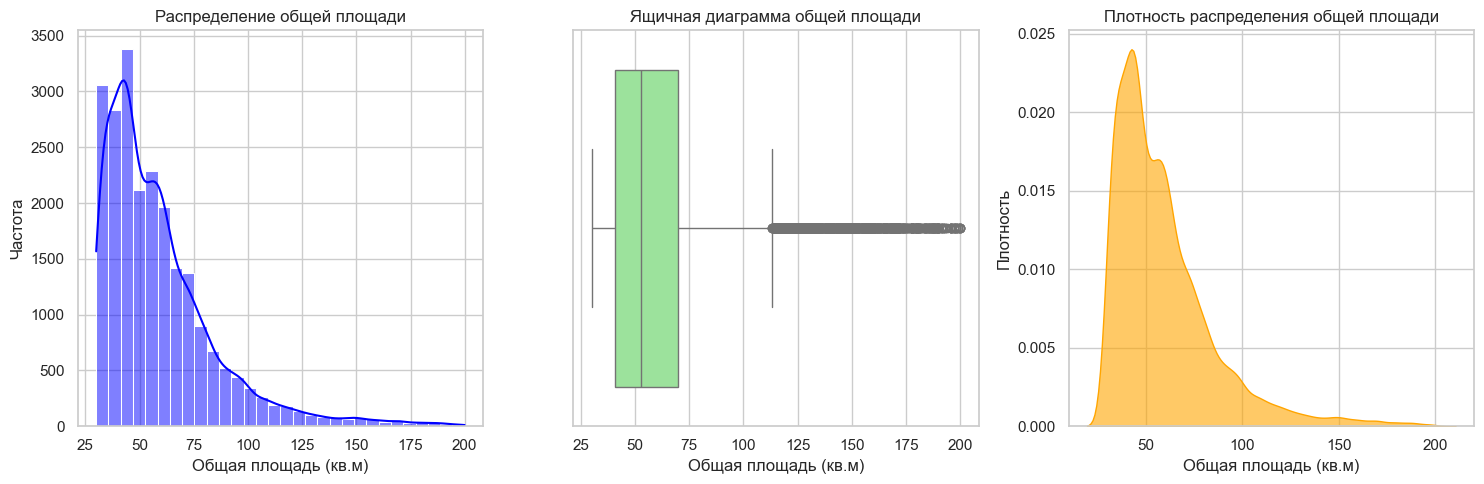

In [145]:
# Проверка распределения после фильтрации
plt.figure(figsize=(15, 5))
# Гистограмма
plt.subplot(1, 3, 1)
sns.histplot(filtered_data['total_area'], bins=30, kde=True, color='blue')
plt.title('Распределение общей площади')
plt.xlabel('Общая площадь (кв.м)')
plt.ylabel('Частота')
# Боксплот
plt.subplot(1, 3, 2)
sns.boxplot(x=filtered_data['total_area'], color='lightgreen')
plt.title('Ящичная диаграмма общей площади')
plt.xlabel('Общая площадь (кв.м)')
# KDE-график
plt.subplot(1, 3, 3)
sns.kdeplot(data=filtered_data, x='total_area', fill=True, color='orange', alpha=0.6)
plt.title('Плотность распределения общей площади')
plt.xlabel('Общая площадь (кв.м)')
plt.ylabel('Плотность')
plt.tight_layout()
plt.show()

2. Взяла минимальное значение комнат - меньше 1 и максимальное число комнат - 6: все эти значения будут удалены.

Описание столбца 'rooms':
count    23699.000000
mean         2.070636
std          1.078405
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64

Уникальные значения и их частота:
rooms
1     8047
2     7940
3     5814
4     1180
5      326
0      197
6      105
7       59
8       12
9        8
10       3
11       2
14       2
15       1
19       1
16       1
12       1
Name: count, dtype: int64


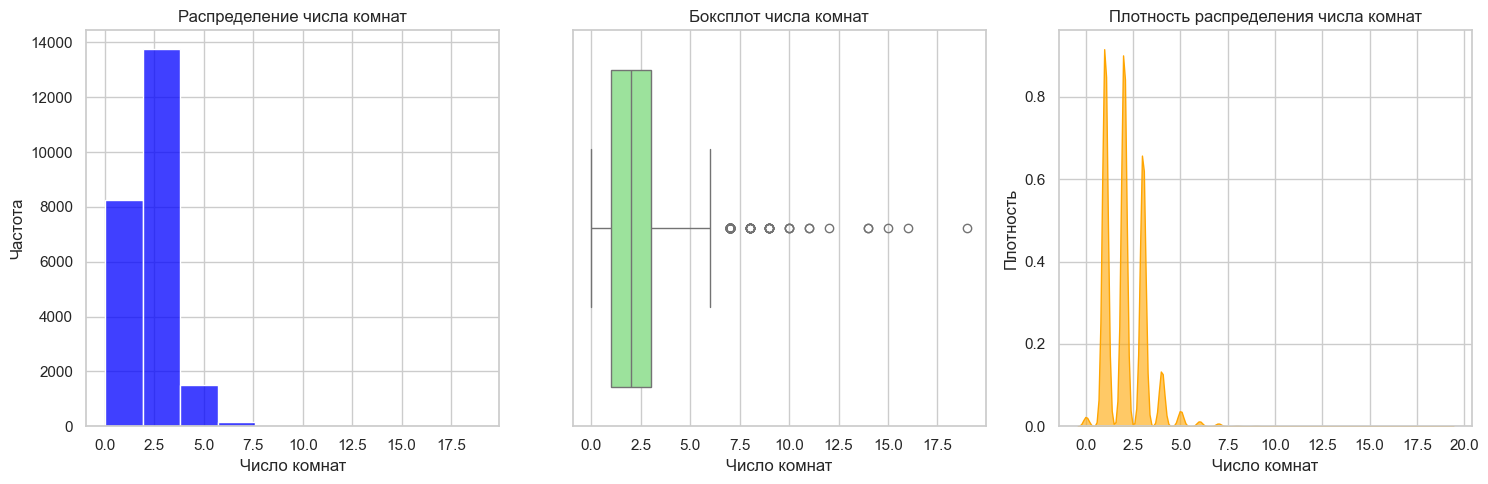

Размер данных до фильтрации: 23699
Размер данных после фильтрации: 23412


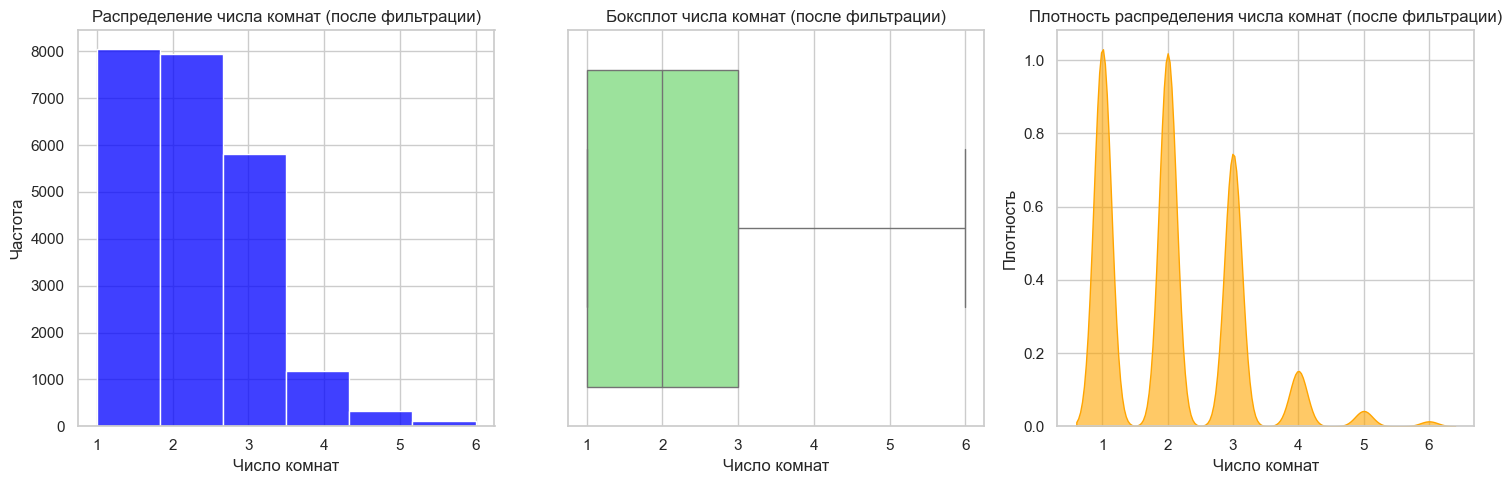


Выводы по числу комнат:
- Наиболее часто встречаются квартиры с 1, 2 и 3 комнатами.
- Были выбросы (например, 0 или больше 6 комнат), которые мы удалили.
- Распределение имеет пик на 1-2 комнатах, что характерно для квартир эконом-класса.


In [146]:
# 1. Проверим распределение значений
print("Описание столбца 'rooms':")
print(realty['rooms'].describe())
print("\nУникальные значения и их частота:")
print(realty['rooms'].value_counts())

# Построение графиков
plt.figure(figsize=(15, 5))
# Гистограмма
plt.subplot(1, 3, 1)
sns.histplot(realty['rooms'], bins=10, kde=False, color='blue')
plt.title('Распределение числа комнат')
plt.xlabel('Число комнат')
plt.ylabel('Частота')
# Боксплот
plt.subplot(1, 3, 2)
sns.boxplot(x=realty['rooms'], color='lightgreen')
plt.title('Боксплот числа комнат')
plt.xlabel('Число комнат')
# KDE-график
plt.subplot(1, 3, 3)
sns.kdeplot(data=realty, x='rooms', fill=True, color='orange', alpha=0.6)
plt.title('Плотность распределения числа комнат')
plt.xlabel('Число комнат')
plt.ylabel('Плотность')
plt.tight_layout()
plt.show()

# 2. Фильтрация значений (оставляем разумные границы)
filtered_rooms = realty[(realty['rooms'] >= 1) & (realty['rooms'] <= 6)]
# Проверка после фильтрации
print(f"Размер данных до фильтрации: {realty.shape[0]}")
print(f"Размер данных после фильтрации: {filtered_rooms.shape[0]}")

# 3. Построение графиков для очищенных данных
plt.figure(figsize=(15, 5))
# Гистограмма
plt.subplot(1, 3, 1)
sns.histplot(filtered_rooms['rooms'], bins=6, kde=False, color='blue')
plt.title('Распределение числа комнат (после фильтрации)')
plt.xlabel('Число комнат')
plt.ylabel('Частота')
# Боксплот
plt.subplot(1, 3, 2)
sns.boxplot(x=filtered_rooms['rooms'], color='lightgreen')
plt.title('Боксплот числа комнат (после фильтрации)')
plt.xlabel('Число комнат')
# KDE-график
plt.subplot(1, 3, 3)
sns.kdeplot(data=filtered_rooms, x='rooms', fill=True, color='orange', alpha=0.6)
plt.title('Плотность распределения числа комнат (после фильтрации)')
plt.xlabel('Число комнат')
plt.ylabel('Плотность')
plt.tight_layout()
plt.show()

# 4. Выводы
print("\nВыводы по числу комнат:")
print("- Наиболее часто встречаются квартиры с 1, 2 и 3 комнатами.")
print("- Были выбросы (например, 0 или больше 6 комнат), которые мы удалили.")
print("- Распределение имеет пик на 1-2 комнатах, что характерно для квартир эконом-класса.")

In [147]:
realty[realty["rooms"]<1]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category
144,1,7350000.0,27.00,2017-03-30T00:00:00,0,NaN,24.0,15.50,2,NaN,...,2.0,Посёлок 4,NaN,NaN,NaN,NaN,NaN,NaN,181.0,Посёлок
349,4,6960000.0,25.00,2017-09-27T00:00:00,0,NaN,14.0,17.00,1,NaN,...,0.0,Деревня 1,NaN,NaN,NaN,NaN,NaN,NaN,45.0,Деревня
440,8,7440000.0,27.11,2018-03-12T00:00:00,0,NaN,17.0,24.75,4,NaN,...,2.0,Город А,38171.0,15015.0,0.0,NaN,2.0,982.0,64.0,Город
508,0,10125000.0,34.40,2017-03-28T00:00:00,0,NaN,26.0,24.30,19,NaN,...,1.0,Посёлок 3,53115.0,19292.0,0.0,NaN,1.0,593.0,430.0,Посёлок
608,2,5550000.0,25.00,2019-02-20T00:00:00,0,NaN,10.0,NaN,7,NaN,...,NaN,Посёлок 1,NaN,NaN,NaN,NaN,NaN,NaN,29.0,Посёлок
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23210,7,9600000.0,26.00,2017-09-01T00:00:00,0,NaN,25.0,18.00,16,NaN,...,0.0,Город А,11405.0,13222.0,0.0,NaN,1.0,623.0,14.0,Город
23442,0,7500000.0,27.70,2017-09-28T00:00:00,0,NaN,24.0,18.00,4,NaN,...,2.0,Посёлок 4,NaN,NaN,NaN,NaN,NaN,NaN,4.0,Посёлок
23554,15,10050000.0,26.00,2018-09-07T00:00:00,0,NaN,19.0,NaN,8,NaN,...,NaN,Город А,18090.0,17092.0,0.0,NaN,2.0,112.0,31.0,Город
23592,10,4350000.0,29.00,2017-11-11T00:00:00,0,NaN,9.0,18.00,8,NaN,...,2.0,Населённый пункт 23,NaN,NaN,NaN,NaN,NaN,NaN,82.0,Населённый пункт


In [148]:
realty[realty["rooms"]<1].iloc[:, 5:15]

,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name
144,NaN,24.0,15.50,2,NaN,True,False,NaN,2.0,Посёлок 4
349,NaN,14.0,17.00,1,NaN,False,True,NaN,0.0,Деревня 1
440,NaN,17.0,24.75,4,NaN,True,False,NaN,2.0,Город А
508,NaN,26.0,24.30,19,NaN,False,True,NaN,1.0,Посёлок 3
608,NaN,10.0,NaN,7,NaN,True,False,NaN,NaN,Посёлок 1
...,...,...,...,...,...,...,...,...,...,...
23210,NaN,25.0,18.00,16,NaN,True,False,NaN,0.0,Город А
23442,NaN,24.0,18.00,4,NaN,False,True,NaN,2.0,Посёлок 4
23554,NaN,19.0,NaN,8,NaN,True,False,NaN,NaN,Город А
23592,NaN,9.0,18.00,8,NaN,False,True,NaN,2.0,Населённый пункт 23


In [149]:
realty = realty[realty['rooms'] >= 1]  # Удаление строк с 0 комнатами

In [151]:
realty = realty[realty['rooms'] <= 6]  # Удаление строк больше 6 комнат

In [152]:
realty['rooms'].describe()  

count    23412.000000
mean         2.065138
std          0.993242
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: rooms, dtype: float64

3. Я установила минимальную высоту потолков на уровне 2.7 м, исключив все значения ниже этого порога. Аналогично, максимальная высота потолков была ограничена 3.5 м, и значения, превышающие этот предел, также подлежат удалению.

In [153]:
realty[realty['ceiling_height']<2.7]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category
9,18,16200000.0,61.0,2017-02-26T00:00:00,3,2.50,9.0,43.6,7,NaN,...,2.0,Город А,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0,Город
10,5,15150000.0,39.6,2017-11-16T00:00:00,1,2.67,12.0,20.3,3,NaN,...,NaN,Город А,38357.0,13878.0,1.0,310.0,2.0,553.0,137.0,Город
13,20,10650000.0,42.8,2017-07-01T00:00:00,2,2.56,5.0,27.0,5,NaN,...,1.0,Населённый пункт 3,37868.0,33058.0,1.0,294.0,3.0,298.0,366.0,Населённый пункт
18,8,9750000.0,31.0,2017-01-27T00:00:00,1,2.50,5.0,19.4,2,NaN,...,1.0,Город А,44060.0,10842.0,1.0,759.0,0.0,NaN,168.0,Город
23,11,8850000.0,32.0,2016-10-29T00:00:00,1,2.60,9.0,17.7,9,NaN,...,NaN,Город А,15414.0,14211.0,2.0,517.0,1.0,190.0,615.0,Город
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23683,16,6300000.0,62.8,2018-09-18T00:00:00,4,2.50,5.0,45.5,3,NaN,...,NaN,Посёлок 201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Посёлок
23685,15,7470000.0,31.0,2019-01-24T00:00:00,1,2.50,5.0,17.3,5,NaN,...,1.0,Населённый пункт 1,48393.0,51818.0,0.0,NaN,0.0,NaN,NaN,Населённый пункт
23686,8,9900000.0,31.0,2017-04-29T00:00:00,1,2.55,9.0,18.0,6,NaN,...,0.0,Город А,11751.0,11602.0,1.0,140.0,1.0,317.0,193.0,Город
23693,9,13800000.0,62.4,2016-08-05T00:00:00,3,2.60,9.0,40.0,8,NaN,...,0.0,Населённый пункт 3,45602.0,34104.0,1.0,352.0,1.0,675.0,239.0,Населённый пункт


In [154]:
realty[realty['ceiling_height']>3.5]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category
154,1,24600000.0,80.00,2018-11-06T00:00:00,3,4.15,3.0,44.20,2,NaN,...,NaN,Город А,20562.0,3167.0,2.0,344.0,1.0,838.0,38.0,Город
179,5,44400000.0,108.70,2019-04-11T00:00:00,3,4.00,5.0,72.40,5,NaN,...,NaN,Город А,23017.0,2559.0,1.0,559.0,0.0,NaN,NaN,Город
355,17,10800000.0,55.20,2018-07-12T00:00:00,2,25.00,5.0,32.00,2,False,...,2.0,Населённый пункт 7,NaN,NaN,NaN,NaN,NaN,NaN,259.0,Населённый пункт
368,19,37500000.0,85.00,2018-09-21T00:00:00,3,3.70,6.0,56.50,6,NaN,...,NaN,Город А,27084.0,5777.0,2.0,516.0,1.0,36.0,4.0,Город
464,15,199713000.0,280.30,2015-06-11T00:00:00,6,5.20,8.0,159.50,7,NaN,...,0.0,Город А,26316.0,6655.0,3.0,187.0,1.0,616.0,578.0,Город
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23014,8,6750000.0,28.30,2017-08-04T00:00:00,1,3.70,3.0,10.90,2,NaN,...,NaN,Населённый пункт 1,49713.0,53138.0,2.0,170.0,3.0,110.0,424.0,Населённый пункт
23330,6,59700000.0,144.00,2017-01-09T00:00:00,3,3.80,5.0,79.50,3,NaN,...,NaN,Город А,24705.0,4924.0,2.0,521.0,0.0,NaN,NaN,Город
23382,2,45000000.0,150.90,2016-07-04T00:00:00,4,3.67,4.0,98.20,3,NaN,...,0.0,Город А,21204.0,2180.0,3.0,105.0,1.0,614.0,455.0,Город
23573,8,18870000.0,47.67,2019-03-20T00:00:00,1,3.60,12.0,13.59,12,NaN,...,2.0,Город А,35726.0,16028.0,1.0,253.0,2.0,99.0,19.0,Город


In [155]:
realty = realty[(realty['ceiling_height'] >= 2.7) & (realty['ceiling_height'] <= 3.5)]   # Очистка данных по высоте потолков 

4. Я удалила записи, в которых количество этажей в доме превышает 40. Этот подход был выбран, поскольку в верхнем датасете максимальное значение количества этажей составляет 60, что значительно выше стандартных значений для большинства зданий. Исключение таких данных помогает избежать влияния аномалий и ошибок на анализ.

In [156]:
realty[realty['floors_total']>40]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category
2253,12,11400000.0,45.5,2018-06-28T00:00:00,2,2.88,60.0,27.4,4,NaN,...,NaN,Населённый пункт 9,67763.0,49488.0,2.0,342.0,3.0,614.0,166.0,Населённый пункт


In [157]:
realty = realty[realty['floors_total'] <= 40]  # Очистка данных столбца всего этажей в доме 

5. Я удалила записи, в которых жилая площадь была менее 20 м², и её доля от общей площади квартиры составляла меньше 10%. Этот подход был выбран, поскольку в верхнем датасете минимальная жилая площадь составляет 2 м², что может быть нереалистичным. Кроме того, доля жилой площади в общей площади менее 10% указывает на диспропорционально большие кухни или другие помещения, что тоже выглядит аномально. Такой фильтр помогает удалить некорректные или подозрительные данные.

In [158]:
realty[(realty['living_area']<20) & (realty['living_area']/realty['total_area']<0.1)]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category
13915,20,19050000.0,52.0,2018-02-06T00:00:00,2,3.0,6.0,2.0,2,NaN,...,NaN,Город А,32453.0,6521.0,0.0,NaN,1.0,1012.0,91.0,Город
23574,14,194970000.0,139.0,2015-11-24T00:00:00,3,3.0,8.0,3.0,8,NaN,...,1.0,Город А,33255.0,5975.0,1.0,630.0,3.0,100.0,280.0,Город


In [159]:
realty = realty[
    (realty['living_area'] >= 20) | 
    (realty['living_area'] / realty['total_area'] >= 0.1)
]                                                                     #  Очистка данных по жилой площади

6. Я удалила записи, в которых площадь кухни была меньше 1 м², либо превышала 40 м², если при этом её доля от общей площади квартиры составляла более 30%. Этот подход был выбран, поскольку в верхнем датасете минимальное значение площади кухни составляет 1.3 м², что делает значения ниже 1 м² явно некорректными. Также кухни с площадью более 40 м², занимающие свыше 30% общей площади квартиры, выглядят непропорционально и могут быть результатом ошибок в данных. Исключение таких записей позволяет улучшить качество анализа.

In [160]:
realty[(realty['kitchen_area']<1) | ((realty['kitchen_area']>40) & (realty['kitchen_area']/realty['total_area']>0.3))].iloc[:, :15]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name
4,2,30000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,False,False,41.0,NaN,Город А
51,7,135000000.0,161.0,2017-10-17T00:00:00,3,3.20,8.0,38.0,4,NaN,False,False,50.0,NaN,Город А
263,12,119700000.0,140.6,2016-11-19T00:00:00,2,3.50,8.0,39.8,7,NaN,False,False,49.2,4.0,Город А
492,18,285000000.0,216.0,2017-12-05T00:00:00,4,3.00,5.0,86.0,4,NaN,False,False,77.0,NaN,Город А
656,10,55500000.0,131.0,2018-10-11T00:00:00,3,2.80,20.0,64.0,19,NaN,False,False,50.0,NaN,Город А
1804,20,41400000.0,114.0,2018-10-29T00:00:00,3,3.40,5.0,51.0,2,NaN,False,False,41.0,1.0,Город А
2175,8,71970000.0,153.0,2015-12-18T00:00:00,4,2.80,25.0,75.0,12,NaN,False,False,46.0,NaN,Город А
2251,20,59850000.0,115.5,2017-04-14T00:00:00,3,2.75,20.0,60.0,9,NaN,False,False,43.0,NaN,Город А
3561,5,36900000.0,115.0,2017-08-09T00:00:00,3,2.70,20.0,45.0,16,NaN,False,False,60.0,1.0,Город А
3906,20,71400000.0,136.0,2015-01-21T00:00:00,2,3.45,4.0,72.0,4,NaN,False,False,42.0,NaN,Город А


In [161]:
realty = realty[
    (realty['kitchen_area'] >= 1) & 
    ((realty['kitchen_area'] <= 40) | (realty['kitchen_area'] / realty['total_area'] <= 0.3))
]                                  #  Очистка данных по площади кухни

7. Я удалила записи, в которых время размещения объявления превышало 450 дней. Этот подход был выбран, так как такие длительные сроки, превышающие 1.5 года, скорее всего, указывают на неактуальные или давно проданные объекты. Исключение подобных данных позволяет сосредоточиться на более релевантных и достоверных записях.

In [162]:
realty[realty['days_exposition']>450]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category
42,13,66000000.0,161.8,2015-07-08T00:00:00,4,2.80,4.0,80.90,2,False,...,5.0,Населённый пункт 3,35416.0,30605.0,2.0,47.0,1.0,907.0,987.0,Населённый пункт
43,13,27990000.0,48.0,2017-01-10T00:00:00,2,3.00,4.0,28.00,4,NaN,...,NaN,Город А,15016.0,10822.0,0.0,NaN,1.0,492.0,763.0,Город
145,6,24870000.0,77.0,2015-09-21T00:00:00,2,2.77,16.0,40.00,5,NaN,...,1.0,Город А,30012.0,7384.0,0.0,NaN,1.0,260.0,807.0,Город
177,3,63126054.0,154.9,2017-09-10T00:00:00,4,3.30,16.0,89.11,3,NaN,...,NaN,Город А,37434.0,8460.0,1.0,441.0,2.0,427.0,563.0,Город
198,7,8700000.0,35.0,2015-02-04T00:00:00,1,2.70,17.0,16.10,17,False,...,2.0,Населённый пункт 13,NaN,NaN,NaN,NaN,NaN,NaN,586.0,Населённый пункт
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23558,17,27600000.0,95.5,2016-02-07T00:00:00,3,2.80,12.0,53.00,9,NaN,...,1.0,Город А,42781.0,9148.0,0.0,NaN,0.0,NaN,900.0,Город
23585,1,17859132.0,89.6,2015-09-03T00:00:00,3,2.75,23.0,47.70,17,NaN,...,NaN,Город А,26726.0,8880.0,0.0,NaN,1.0,624.0,939.0,Город
23648,14,30300000.0,78.0,2017-05-12T00:00:00,3,3.27,5.0,48.60,5,NaN,...,NaN,Город А,20933.0,1113.0,1.0,621.0,2.0,117.0,621.0,Город
23664,5,27000000.0,110.0,2015-12-10T00:00:00,4,3.36,7.0,64.60,5,NaN,...,NaN,Город А,26313.0,5016.0,3.0,417.0,1.0,118.0,816.0,Город


In [163]:
realty = realty[realty['days_exposition'] <= 450]  # Очистка данных по времени размещения объявления

In [164]:
realty.describe()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
count,4155.000000,4.155000e+03,4155.000000,4155.000000,4155.000000,4155.000000,4155.000000,4155.000000,4155.000000,2365.000000,3453.000000,3463.000000,3463.000000,1706.000000,3463.000000,1854.000000,4155.000000
mean,10.469555,2.391271e+07,67.455427,2.116486,2.869550,11.960048,37.481841,6.464501,12.228984,1.358985,28365.708370,12263.006642,0.716431,477.304220,0.895755,498.229773,131.611793
std,5.755048,3.043274e+07,34.874243,1.037527,0.192976,7.223967,22.803753,5.225431,5.385566,1.115993,11806.181956,8036.664059,0.870190,351.485208,1.026985,277.717264,113.234886
min,0.000000,1.500000e+06,17.000000,1.000000,2.700000,1.000000,8.500000,1.000000,2.000000,0.000000,0.000000,287.000000,0.000000,10.000000,0.000000,16.000000,2.000000
25%,6.000000,1.305000e+07,43.000000,1.000000,2.700000,5.000000,20.000000,3.000000,9.000000,1.000000,19508.000000,6079.500000,0.000000,263.000000,0.000000,270.250000,43.000000
50%,10.000000,1.800000e+07,60.000000,2.000000,2.800000,10.000000,32.900000,5.000000,11.000000,1.000000,26086.000000,11903.000000,0.000000,435.000000,1.000000,473.000000,95.000000
75%,15.000000,2.640000e+07,80.000000,3.000000,3.000000,17.000000,48.000000,9.000000,13.800000,2.000000,36413.000000,15114.000000,1.000000,599.250000,1.000000,706.000000,193.000000
max,32.000000,9.900000e+08,488.000000,6.000000,3.500000,35.000000,300.000000,27.000000,56.000000,5.000000,73827.000000,54926.000000,3.000000,3013.000000,3.000000,1313.000000,450.000000


In [165]:
realty[realty.duplicated()]  # Выводим дубликаты

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category


In [166]:
realty['balcony'].value_counts()  # Выводим уникальные значения столбцов

balcony
2.0    877
1.0    787
0.0    547
5.0     77
4.0     57
3.0     20
Name: count, dtype: int64

In [167]:
realty['is_apartment'].value_counts()  # Выводим уникальные значения столбцов

is_apartment
False    621
True      11
Name: count, dtype: int64

In [168]:
# Вычисляем средние доли жилой площади и площади кухни
avg_living_ratio = (realty['living_area'] / realty['total_area']).mean()
avg_kitchen_ratio = (realty['kitchen_area'] / realty['total_area']).mean()

# Выводим средние доли для проверки
print(f"Средняя доля жилой площади: {avg_living_ratio:.2f}")
print(f"Средняя доля площади кухни: {avg_kitchen_ratio:.2f}")

# Заполняем пропуски
realty['ceiling_height'] = realty['ceiling_height'].fillna(realty['ceiling_height'].median())  # Высота потолков
realty['floors_total'] = realty['floors_total'].fillna(realty['floors_total'].median())       # Этажность здания
realty['living_area'] = realty['living_area'].fillna(realty['total_area'] * avg_living_ratio)  # Жилая площадь
realty['kitchen_area'] = realty['kitchen_area'].fillna(realty['total_area'] * avg_kitchen_ratio)  # Площадь кухни
realty['balcony'] = realty['balcony'].fillna(0)  # Балконы
realty['is_apartment'] = realty['is_apartment'].fillna(False)  # Апартаменты
realty['airports_nearest'] = realty['airports_nearest'].fillna(realty['airports_nearest'].median())  # Расстояние до ближайшего аэропорта
realty['cityCenters_nearest'] = realty['cityCenters_nearest'].fillna(realty['cityCenters_nearest'].median())  # Расстояние до центра города
realty['parks_around3000'] = realty['parks_around3000'].fillna(0)  # Число парков в радиусе 3 км
realty['ponds_around3000'] = realty['ponds_around3000'].fillna(0)  # Число водоемов в радиусе 3 км
realty['parks_nearest'] = realty['parks_nearest'].fillna(realty['parks_nearest'].median())  # Расстояние до ближайшего парка
realty['ponds_nearest'] = realty['ponds_nearest'].fillna(realty['ponds_nearest'].median())  # Расстояние до ближайшего водоема
realty['days_exposition'] = realty['days_exposition'].fillna(realty['days_exposition'].median())  # Сколько дней было размещено объявление

# Проверяем оставшиеся пропуски
print("Пропуски после заполнения:")
print(realty.isna().sum())

Средняя доля жилой площади: 0.54
Средняя доля площади кухни: 0.20
Пропуски после заполнения:
total_images            0
last_price              0
total_area              0
first_day_exposition    0
rooms                   0
ceiling_height          0
floors_total            0
living_area             0
floor                   0
is_apartment            0
studio                  0
open_plan               0
kitchen_area            0
balcony                 0
locality_name           0
airports_nearest        0
cityCenters_nearest     0
parks_around3000        0
parks_nearest           0
ponds_around3000        0
ponds_nearest           0
days_exposition         0
category                0
dtype: int64


C:\Users\Zere\AppData\Local\Temp\ipykernel_96824\615447396.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  realty['is_apartment'] = realty['is_apartment'].fillna(False)  # Апартаменты


In [169]:
# Приведение типов данных
realty['first_day_exposition'] = pd.to_datetime(realty['first_day_exposition'])
realty['floors_total'] = realty['floors_total'].astype('int')
realty['balcony'] = realty['balcony'].astype('int')
realty['category'] = realty['category'].astype('str')

In [170]:
realty.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4155 entries, 16 to 23689
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          4155 non-null   int64         
 1   last_price            4155 non-null   float64       
 2   total_area            4155 non-null   float64       
 3   first_day_exposition  4155 non-null   datetime64[ns]
 4   rooms                 4155 non-null   int64         
 5   ceiling_height        4155 non-null   float64       
 6   floors_total          4155 non-null   int64         
 7   living_area           4155 non-null   float64       
 8   floor                 4155 non-null   int64         
 9   is_apartment          4155 non-null   bool          
 10  studio                4155 non-null   bool          
 11  open_plan             4155 non-null   bool          
 12  kitchen_area          4155 non-null   float64       
 13  balcony              

In [171]:
realty.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,category
16,11,20100000.0,82.0,2017-11-23,3,3.05,5,55.6,1,False,...,0,Город А,22108.0,10698.0,3.0,420.0,0.0,473.0,397.0,Город
19,16,42600000.0,121.0,2019-01-09,3,2.75,16,76.0,8,False,...,0,Город А,38900.0,12843.0,0.0,435.0,0.0,473.0,97.0,Город
20,12,18360000.0,80.0,2017-09-28,3,2.70,27,48.0,11,False,...,2,Посёлок 3,53134.0,19311.0,0.0,435.0,0.0,473.0,74.0,Посёлок
22,20,15000000.0,58.0,2017-04-24,2,2.75,25,30.0,15,False,...,2,Деревня 1,26086.0,11903.0,0.0,435.0,0.0,473.0,60.0,Деревня
25,3,20400000.0,76.0,2015-10-01,2,2.75,23,39.0,18,False,...,2,Город А,34967.0,14640.0,0.0,435.0,1.0,564.0,300.0,Город
28,8,12510000.0,44.0,2017-12-13,1,2.90,6,20.8,1,False,...,1,Населённый пункт 4,18557.0,30710.0,0.0,435.0,1.0,118.0,74.0,Населённый пункт
31,8,21600000.0,67.9,2017-10-26,2,2.80,16,38.1,4,False,...,2,Город А,32888.0,12944.0,0.0,435.0,0.0,473.0,112.0,Город
38,10,9450000.0,40.0,2018-03-29,1,2.75,18,16.3,9,False,...,0,Посёлок 4,26086.0,11903.0,0.0,435.0,0.0,473.0,103.0,Посёлок
39,15,15600000.0,54.4,2018-11-29,2,2.75,9,29.7,2,False,...,2,Город А,13413.0,12209.0,0.0,435.0,1.0,1175.0,29.0,Город
50,1,13500000.0,48.2,2017-11-13,1,2.70,5,25.4,4,False,...,1,Населённый пункт 4,19841.0,30183.0,1.0,531.0,3.0,330.0,152.0,Населённый пункт


# 3. Расчет и добавление в таблицу новых столбцов.

In [172]:
# Цена квадратного метра
realty['price_per_sqm'] = realty['last_price'] / realty['total_area']

realty['publication_weekday'] = realty['first_day_exposition'].dt.dayofweek  # День недели
realty['publication_month'] = realty['first_day_exposition'].dt.month  # Месяц
realty['publication_year'] = realty['first_day_exposition'].dt.year  # Год

# Этаж квартиры
realty['floor_type'] = realty.apply(
    lambda row: 'первый' if row['floor'] == 1 else ('последний' if row['floor'] == row['floors_total'] else 'другой'),
    axis=1
)

# Соотношение жилой и общей площади, площадь кухни к общей
realty['living_area_ratio'] = realty['living_area'] / realty['total_area']
realty['kitchen_area_ratio'] = realty['kitchen_area'] / realty['total_area']

In [173]:
realty.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4155 entries, 16 to 23689
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          4155 non-null   int64         
 1   last_price            4155 non-null   float64       
 2   total_area            4155 non-null   float64       
 3   first_day_exposition  4155 non-null   datetime64[ns]
 4   rooms                 4155 non-null   int64         
 5   ceiling_height        4155 non-null   float64       
 6   floors_total          4155 non-null   int64         
 7   living_area           4155 non-null   float64       
 8   floor                 4155 non-null   int64         
 9   is_apartment          4155 non-null   bool          
 10  studio                4155 non-null   bool          
 11  open_plan             4155 non-null   bool          
 12  kitchen_area          4155 non-null   float64       
 13  balcony              

In [174]:
pd.isnull(realty).sum()

total_images            0
last_price              0
total_area              0
first_day_exposition    0
rooms                   0
ceiling_height          0
floors_total            0
living_area             0
floor                   0
is_apartment            0
studio                  0
open_plan               0
kitchen_area            0
balcony                 0
locality_name           0
airports_nearest        0
cityCenters_nearest     0
parks_around3000        0
parks_nearest           0
ponds_around3000        0
ponds_nearest           0
days_exposition         0
category                0
price_per_sqm           0
publication_weekday     0
publication_month       0
publication_year        0
floor_type              0
living_area_ratio       0
kitchen_area_ratio      0
dtype: int64

# 4. Проведение исследовательского анализа данных.

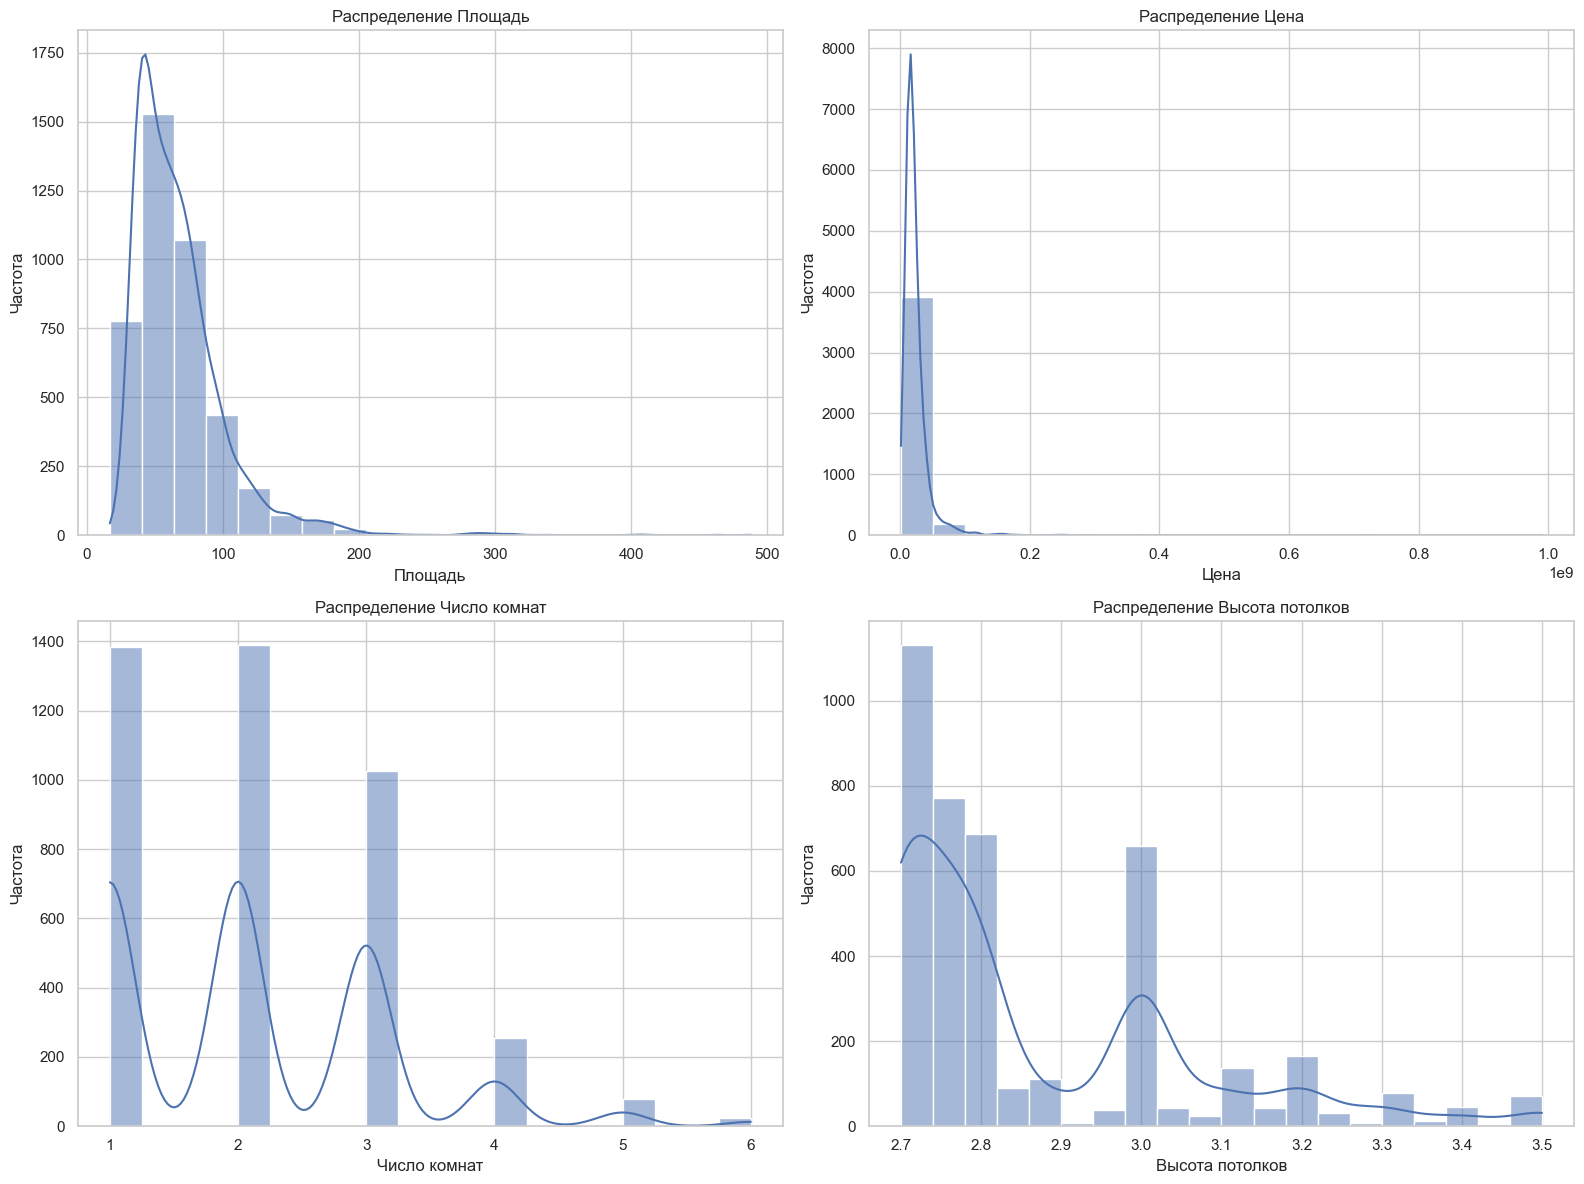

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns

# Параметры для анализа
columns_to_analyze = ['total_area', 'last_price', 'rooms', 'ceiling_height']
titles = ['Площадь', 'Цена', 'Число комнат', 'Высота потолков']

# Построение гистограмм
plt.figure(figsize=(16, 12))
for i, column in enumerate(columns_to_analyze):
    plt.subplot(2, 2, i + 1)
    sns.histplot(realty[column], bins=20, kde=True)
    plt.title(f'Распределение {titles[i]}')
    plt.xlabel(titles[i])
    plt.ylabel('Частота')

plt.tight_layout()
plt.show()

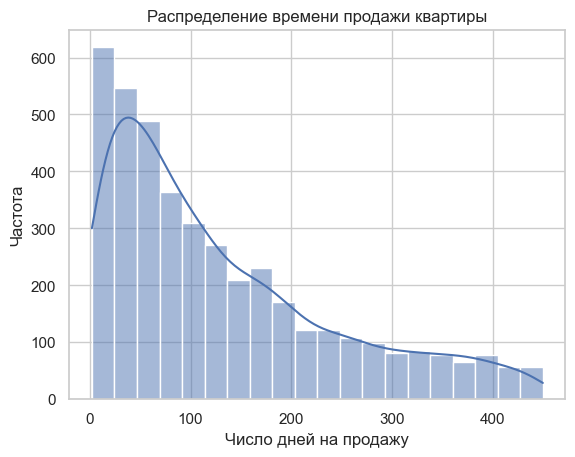

Среднее время продажи: 131.61 дней
Медианное время продажи: 95.0 дней
Продажи считаются быстрыми, если они быстрее 43.0 дней.
Продажи считаются долгими, если они дольше 193.00000000000003 дней.


In [176]:
# Гистограмма для времени продажи
sns.histplot(realty['days_exposition'], bins=20, kde=True)
plt.title('Распределение времени продажи квартиры')
plt.xlabel('Число дней на продажу')
plt.ylabel('Частота')
plt.show()

# Среднее и медиана
mean_days = realty['days_exposition'].mean()
median_days = realty['days_exposition'].median()

# Квартильные границы
q1 = realty['days_exposition'].quantile(0.25)
q3 = realty['days_exposition'].quantile(0.75)

print(f"Среднее время продажи: {mean_days:.2f} дней")
print(f"Медианное время продажи: {median_days} дней")
print(f"Продажи считаются быстрыми, если они быстрее {q1} дней.")
print(f"Продажи считаются долгими, если они дольше {q3} дней.")

In [177]:
# Функция для удаления выбросов методом IQR
def remove_outliers_iqr(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Применение фильтрации
columns_to_filter = ['total_area', 'last_price', 'rooms', 'ceiling_height']
filtered_data = realty.copy()

for column in columns_to_filter:
    filtered_data = remove_outliers_iqr(filtered_data, column)

print(f"Количество данных до фильтрации: {len(realty)}")
print(f"Количество данных после фильтрации: {len(filtered_data)}")

Количество данных до фильтрации: 4155
Количество данных после фильтрации: 3743


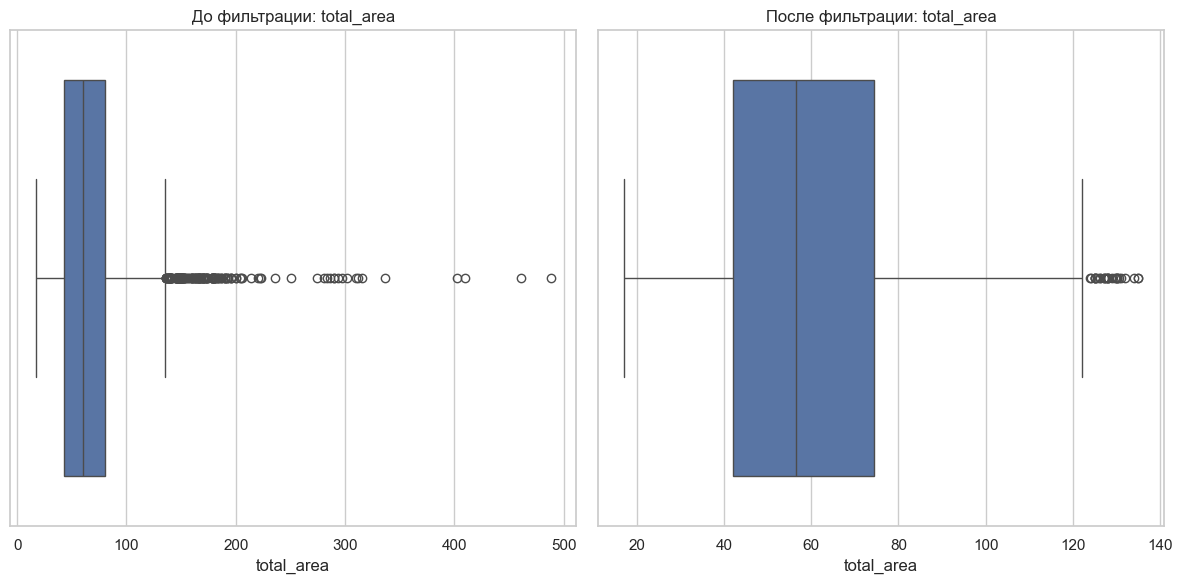

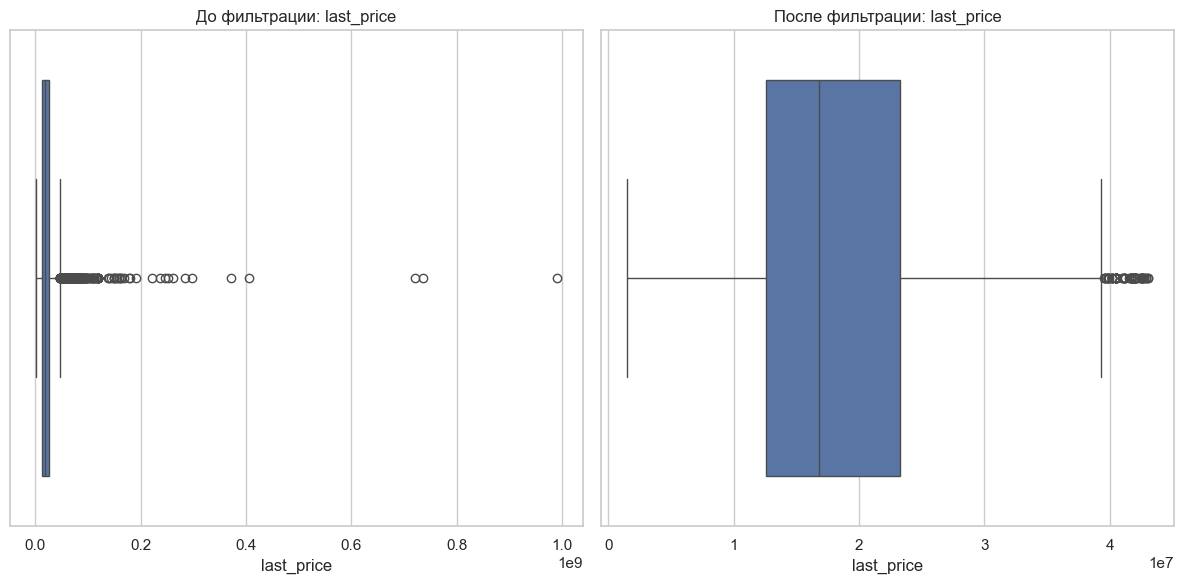

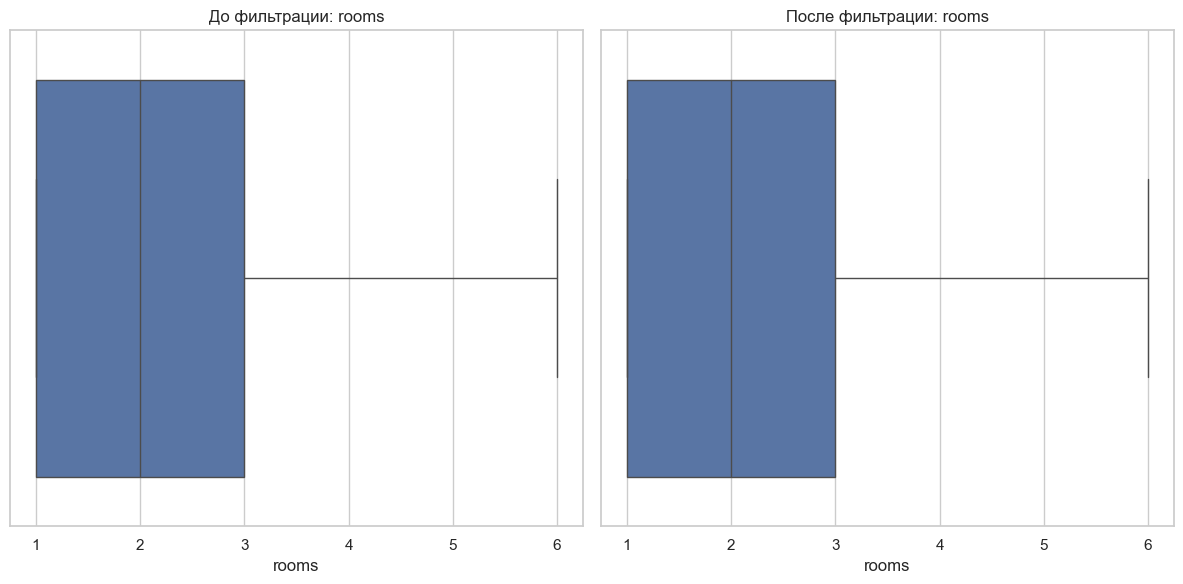

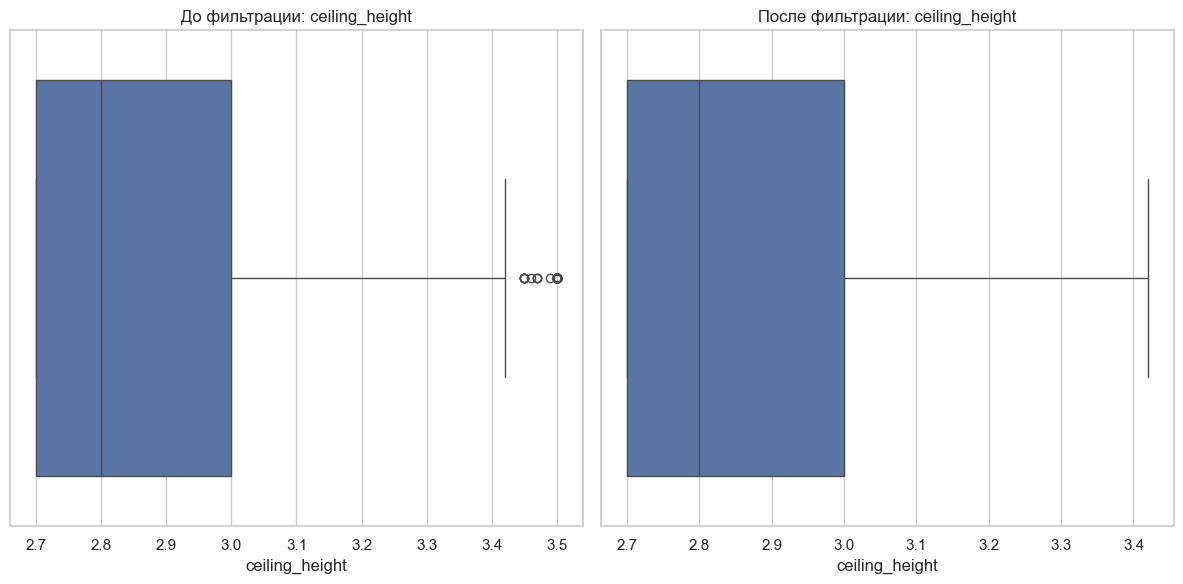

In [178]:
# Ящичные диаграммы до и после фильтрации
for column in columns_to_filter:
    plt.figure(figsize=(12, 6))

    # До фильтрации
    plt.subplot(1, 2, 1)
    sns.boxplot(data=realty, x=column)
    plt.title(f'До фильтрации: {column}')

    # После фильтрации
    plt.subplot(1, 2, 2)
    sns.boxplot(data=filtered_data, x=column)
    plt.title(f'После фильтрации: {column}')

    plt.tight_layout()
    plt.show()

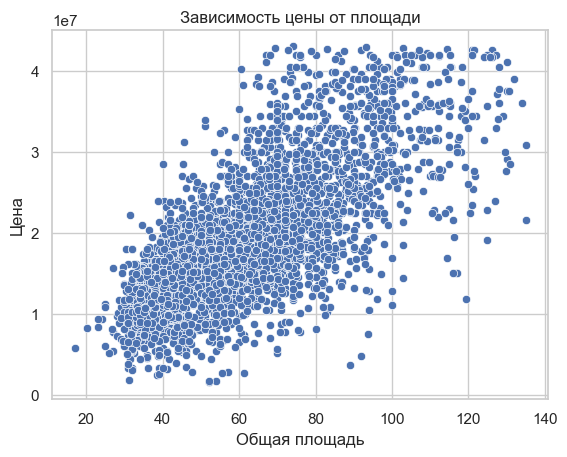

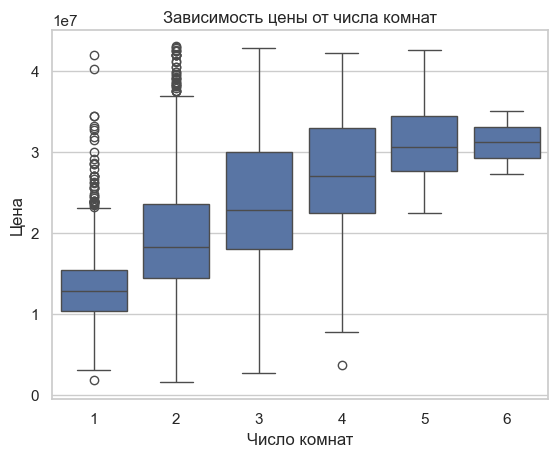

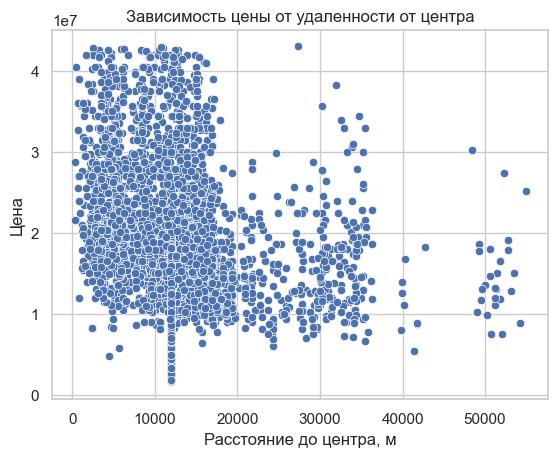

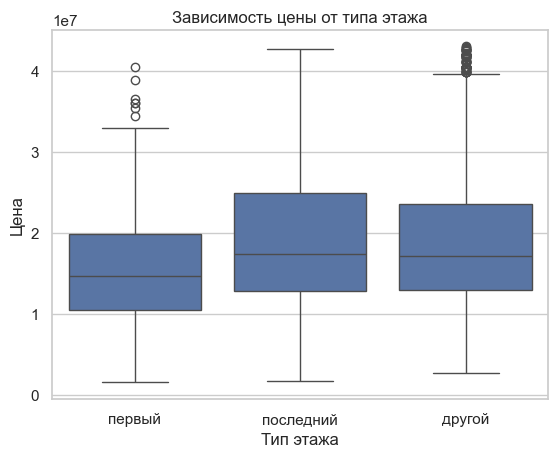

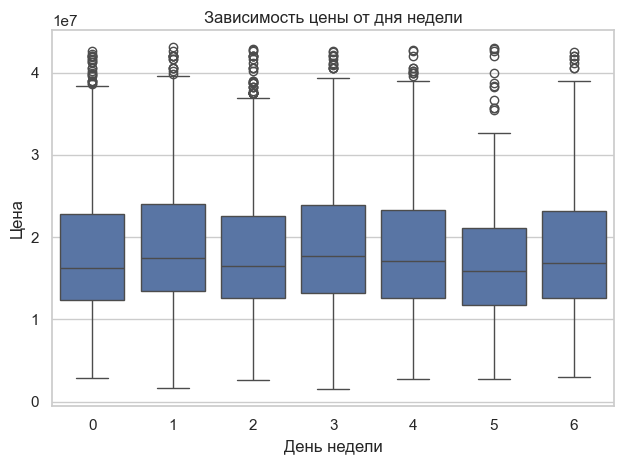

In [179]:
# Зависимость цены от площади
sns.scatterplot(data=filtered_data, x='total_area', y='last_price')
plt.title('Зависимость цены от площади')
plt.xlabel('Общая площадь')
plt.ylabel('Цена')
plt.show()

# Зависимость цены от числа комнат
sns.boxplot(data=filtered_data, x='rooms', y='last_price')
plt.title('Зависимость цены от числа комнат')
plt.xlabel('Число комнат')
plt.ylabel('Цена')
plt.show()

# Зависимость цены от удаленности от центра
sns.scatterplot(data=filtered_data, x='cityCenters_nearest', y='last_price')
plt.title('Зависимость цены от удаленности от центра')
plt.xlabel('Расстояние до центра, м')
plt.ylabel('Цена')
plt.show()

# Зависимость цены от типа этажа
sns.boxplot(data=filtered_data, x='floor_type', y='last_price', order=['первый', 'последний', 'другой'])
plt.title('Зависимость цены от типа этажа')
plt.xlabel('Тип этажа')
plt.ylabel('Цена')
plt.show()

# Зависимость цены от даты публикации
sns.boxplot(data=filtered_data, x='publication_weekday', y='last_price')
plt.title('Зависимость цены от дня недели')
plt.xlabel('День недели')
plt.ylabel('Цена')

plt.tight_layout()
plt.show()

1. Зависимость цены от общей площади
Анализ:
На scatterplot видно, что существует положительная зависимость между общей площадью квартиры (total_area) и ее ценой (last_price):
чем больше площадь квартиры, тем выше ее стоимость. Однако зависимость не идеальная — точки рассредоточены, что может говорить о влиянии других факторов, таких как расположение, состояние квартиры или дополнительные удобства. Также заметны выбросы (отдельные точки далеко от основной массы данных), где цена значительно выше.

2. Зависимость цены от числа комнат
Анализ:
Boxplot показывает, что цена квартиры увеличивается с числом комнат (rooms), но зависимость не всегда линейная.
Внутри категорий (число комнат) есть значительная вариативность цен, что может указывать на влияние дополнительных факторов, таких как расположение или площадь.
Например, квартиры с тем же числом комнат, но разной площадью, будут стоить по-разному. Вероятно, выбросы находятся среди квартир с меньшим числом комнат, но непропорционально высокой ценой (элитное жилье).

3. Зависимость цены от удаленности от центра
Анализ:
На scatterplot с удаленностью от центра (cityCenters_nearest) видно, что чем ближе квартира к центру города, тем выше ее цена. Точки сгруппированы плотно для небольших расстояний, а затем наблюдается снижение цен по мере увеличения расстояния от центра. Однако есть исключения — удаленные квартиры с высокой ценой, возможно, это элитное жилье за пределами центра.

4. Зависимость цены от типа этажа
Анализ:
Boxplot показывает, что квартиры на "первом этаже" и "последнем этаже" обычно дешевле, чем на "других этажах". Вероятно, это связано с предпочтениями покупателей, которые считают средние этажи более комфортными (лучший вид, меньше шума и т.д.). Однако даже среди этих категорий наблюдаются выбросы — квартиры с необычно высокой ценой.

5. Зависимость цены от даты публикации
Анализ:
Boxplot по дням недели (publication_weekday) показывает, как цены меняются в зависимости от дня публикации объявления. Возможно, в определенные дни недели наблюдается большее количество публикаций с более низкими или высокими ценами. Однако на графике виден разброс цен, что говорит о том, что день недели имеет минимальное влияние на стоимость квартиры.

Общие выводы:
Площадь и близость к центру являются ключевыми факторами, влияющими на стоимость квартиры.
Количество комнат также важно, но его влияние менее выражено из-за разброса цен.
Тип этажа играет роль: средние этажи стоят дороже.
День публикации имеет незначительное влияние на цену.

Создала второй график, для эксперимента

C:\Users\Zere\AppData\Local\Temp\ipykernel_96824\416894562.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_data, x='rooms', y='last_price', palette='muted')
C:\Users\Zere\AppData\Local\Temp\ipykernel_96824\416894562.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=filtered_data, x='floor_type', y='last_price', palette='muted', inner='point')


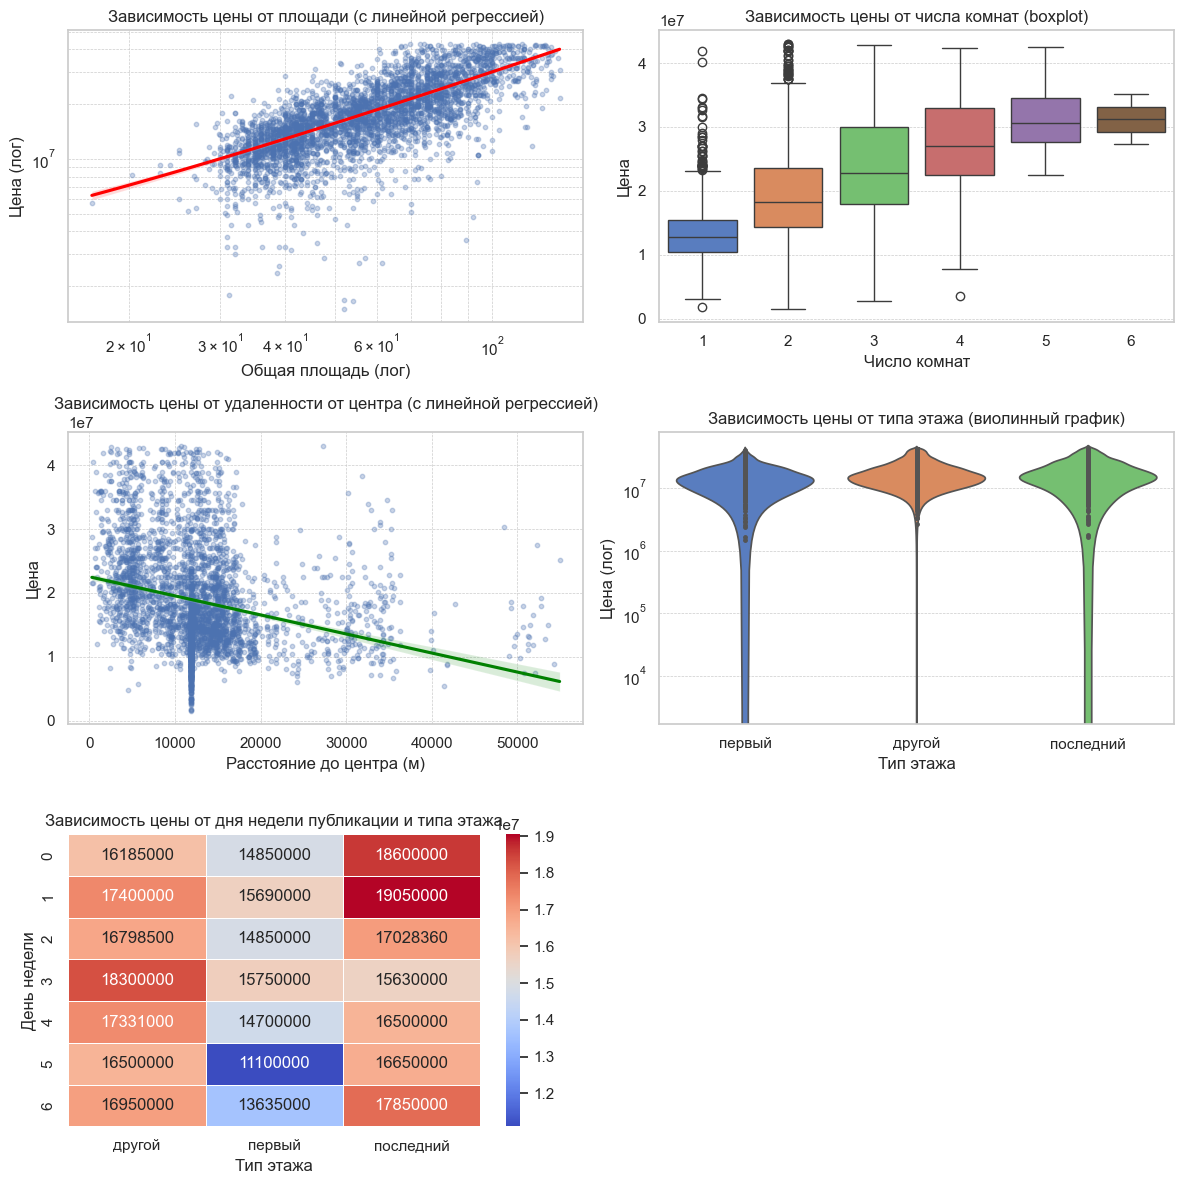

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

# Установим размер для всех графиков
plt.figure(figsize=(12, 12))

# Зависимость цены от площади (график с линией регрессии)
plt.subplot(3, 2, 1)
sns.regplot(data=filtered_data, x='total_area', y='last_price', scatter_kws={'s': 10, 'alpha': 0.3}, line_kws={"color": "red"})
plt.xscale('log')
plt.yscale('log')
plt.title('Зависимость цены от площади (с линейной регрессией)')
plt.xlabel('Общая площадь (лог)')
plt.ylabel('Цена (лог)')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)

# Зависимость цены от числа комнат (график boxplot)
plt.subplot(3, 2, 2)
sns.boxplot(data=filtered_data, x='rooms', y='last_price', palette='muted')
plt.title('Зависимость цены от числа комнат (boxplot)')
plt.xlabel('Число комнат')
plt.ylabel('Цена')
plt.grid(axis='y', linestyle='--', linewidth=0.5)

# Зависимость цены от удаленности от центра (график с точками и линией тренда)
plt.subplot(3, 2, 3)
sns.regplot(data=filtered_data, x='cityCenters_nearest', y='last_price', scatter_kws={'s': 10, 'alpha': 0.3}, line_kws={"color": "green"})
plt.title('Зависимость цены от удаленности от центра (с линейной регрессией)')
plt.xlabel('Расстояние до центра (м)')
plt.ylabel('Цена')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)

# Зависимость цены от типа этажа (график с плотностью распределения)
plt.subplot(3, 2, 4)
sns.violinplot(data=filtered_data, x='floor_type', y='last_price', palette='muted', inner='point')
plt.yscale('log')
plt.title('Зависимость цены от типа этажа (виолинный график)')
plt.xlabel('Тип этажа')
plt.ylabel('Цена (лог)')
plt.grid(axis='y', linestyle='--', linewidth=0.5)

# Зависимость цены от дня недели публикации (с тепловой картой плотности)
plt.subplot(3, 2, 5)
sns.heatmap(filtered_data.pivot_table(values='last_price', index='publication_weekday', columns='floor_type', aggfunc='median'),
            cmap="coolwarm", annot=True, fmt='.0f', linewidths=0.5)
plt.title('Зависимость цены от дня недели публикации и типа этажа')
plt.xlabel('Тип этажа')
plt.ylabel('День недели')

# Выводим все графики в одном окне
plt.tight_layout()
plt.show()

In [181]:
# Топ-10 населённых пунктов по количеству объявлений
top_localities = realty['locality_name'].value_counts().head(10)

# Средняя цена квадратного метра в этих населённых пунктах
realty_top_localities = realty[realty['locality_name'].isin(top_localities.index)]
average_price_per_sqm = realty_top_localities.groupby('locality_name')['price_per_sqm'].mean()

# Выводим результаты
print(average_price_per_sqm)

locality_name
Город А                367040.949895
Деревня 1              274563.166876
Деревня 3              226008.398815
Населённый пункт 13    206996.273244
Населённый пункт 17    315299.487641
Населённый пункт 26    310656.363885
Населённый пункт 4     323303.122654
Населённый пункт 6     229104.963112
Посёлок 1              240110.499825
Посёлок 4              265283.737403
Name: price_per_sqm, dtype: float64


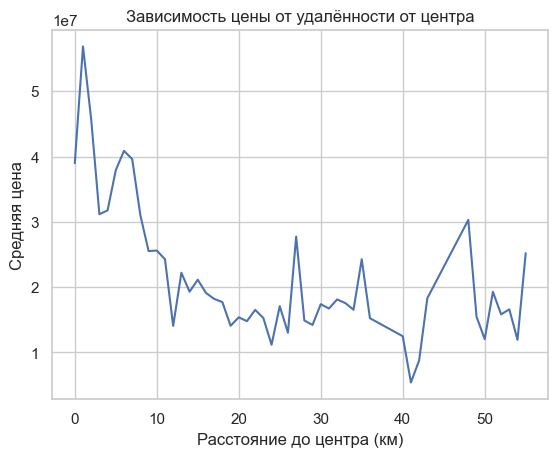

In [182]:
# Преобразуем расстояние в километры
realty['distance_to_center_km'] = (realty['cityCenters_nearest'] / 1000).round()

# Средняя цена для каждого километра
avg_price_by_distance = realty.groupby('distance_to_center_km')['last_price'].mean()

# Построение графика
sns.lineplot(x=avg_price_by_distance.index, y=avg_price_by_distance.values)
plt.title('Зависимость цены от удалённости от центра')
plt.xlabel('Расстояние до центра (км)')
plt.ylabel('Средняя цена')
plt.show()

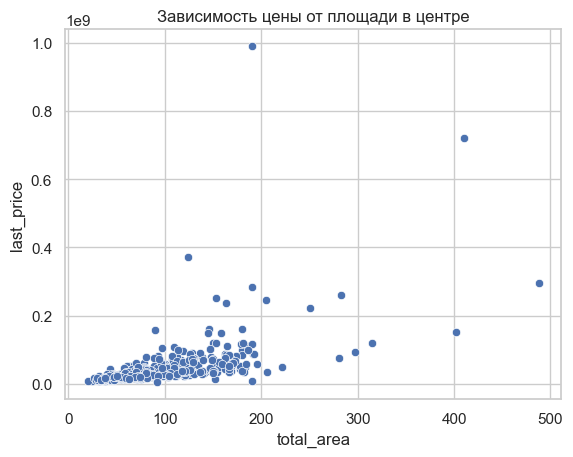

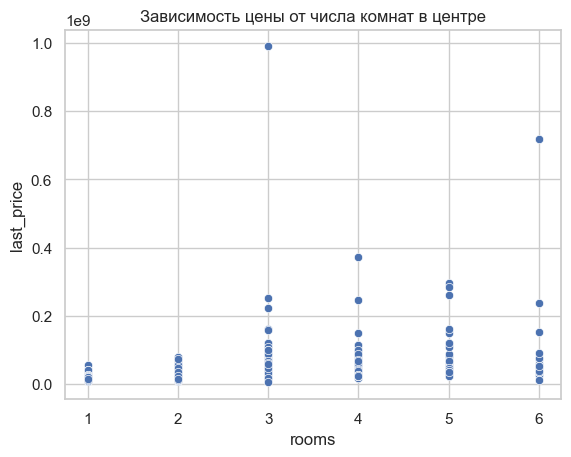

In [183]:
# Фильтруем квартиры в центре
central_area = realty[realty['distance_to_center_km'] <= 5]

# Анализируем параметры квартир в центре
central_area_description = central_area[['total_area', 'last_price', 'rooms', 'ceiling_height']].describe()

# Зависимость цены от разных факторов в центре
sns.scatterplot(x=central_area['total_area'], y=central_area['last_price'])
plt.title('Зависимость цены от площади в центре')
plt.show()

sns.scatterplot(x=central_area['rooms'], y=central_area['last_price'])
plt.title('Зависимость цены от числа комнат в центре')
plt.show()